# Exploratory Data Analysis — Loan Default Prediction
**Projet MLOps | Banque de détail**  
Objectif : analyser le jeu de données de prêts afin de comprendre les variables qui prédisent le défaut de paiement.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

In [7]:
DATA_PATH = '../Data/Loan_Data.csv'

## Informations générales

In [8]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 8)


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [10]:
df.describe().round(2)

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,4974577.00,1.46,4159.68,8718.92,70039.90,4.55,637.56,0.19
std,2293889.71,1.74,1421.40,6627.16,20072.21,1.57,60.66,0.39
min,1000324.00,0.00,46.78,31.65,1000.00,0.00,408.00,0.00
25%,2977661.00,0.00,3154.24,4199.84,56539.87,3.00,597.00,0.00
50%,4989501.50,1.00,4052.38,6732.41,70085.83,5.00,638.00,0.00
75%,6967210.25,2.00,5052.90,11272.26,83429.17,6.00,679.00,0.00
max,8999789.00,5.00,10750.68,43688.78,148412.18,10.00,850.00,1.00


## Valeurs manquantes

In [11]:
df.isnull().sum()

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

## Corrélations

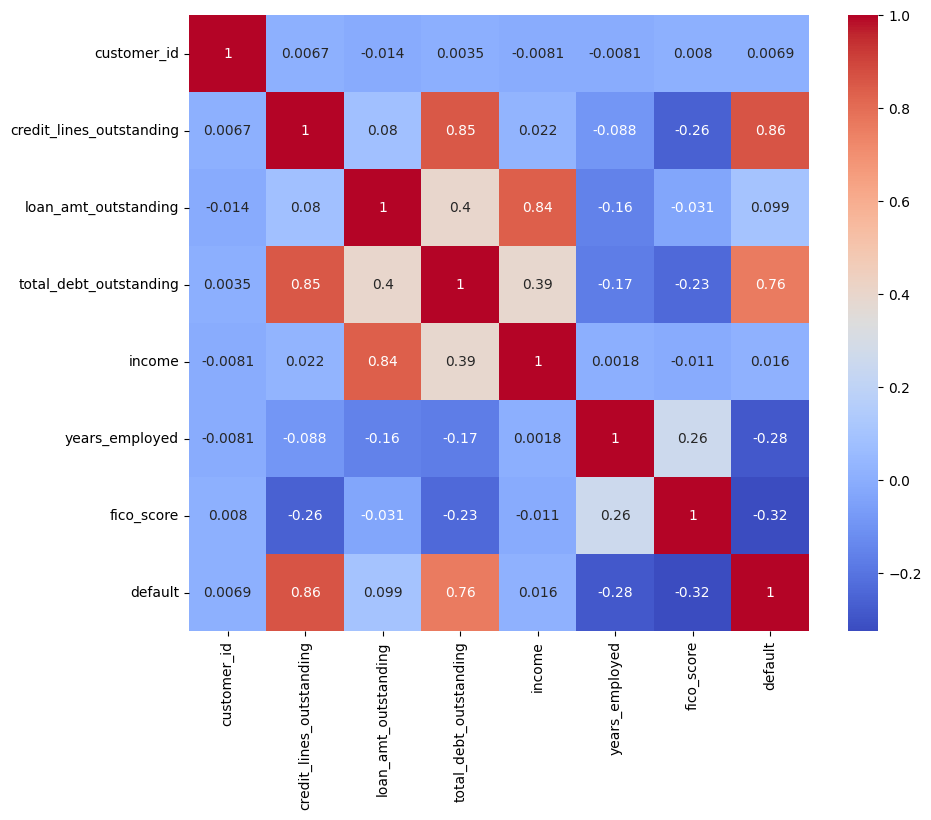

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

## Variable cible

In [14]:
df['default'].value_counts()

default
0    8149
1    1851
Name: count, dtype: int64

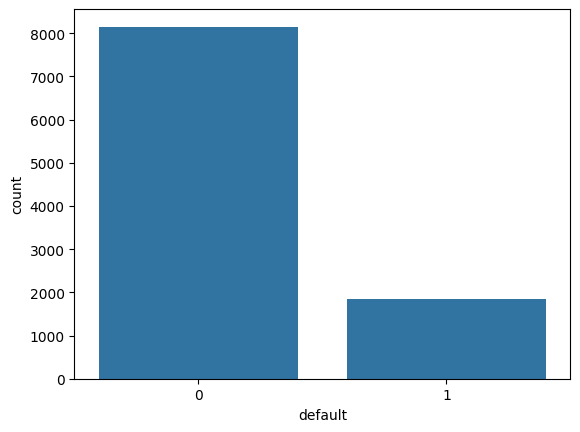

In [15]:
sns.countplot(x='default', data=df)
plt.show()

## Analyse des variables numériques

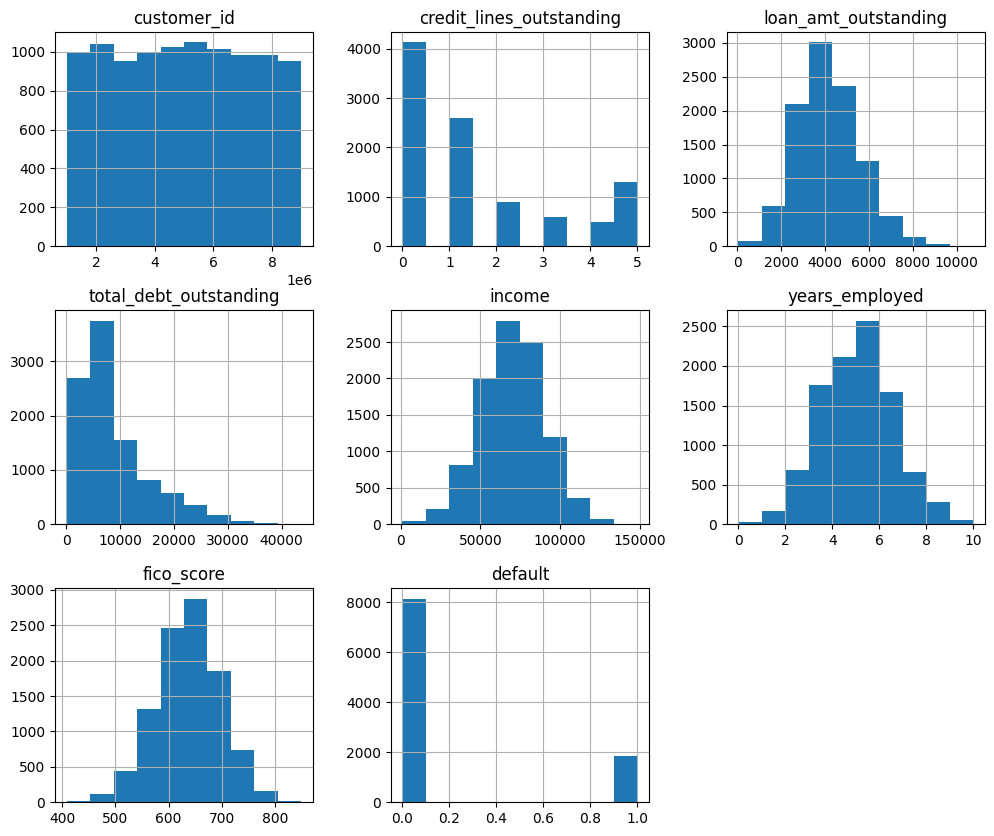

In [16]:
df.hist(figsize=(12,10))
plt.show()

## Relation avec la variable cible

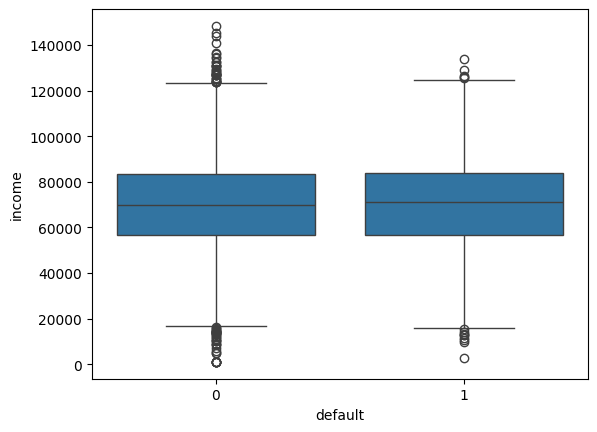

In [17]:
sns.boxplot(x='default', y='income', data=df)
plt.show()

Nous analysons l’influence de certaines variables sur le défaut. Par exemple, les clients avec un revenu plus faible semblent présenter un risque plus élevé.

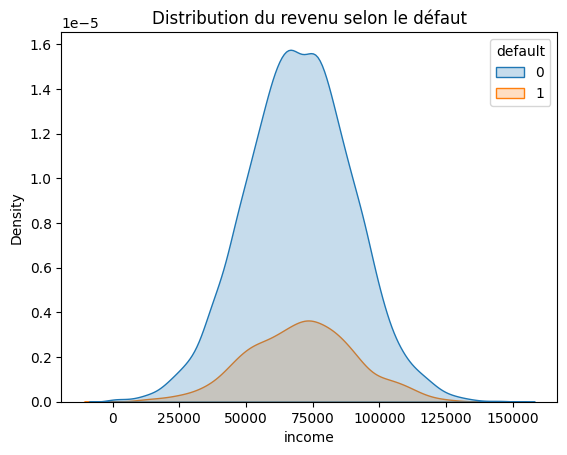

In [20]:
sns.kdeplot(data=df, x="income", hue="default", fill=True)
plt.title("Distribution du revenu selon le défaut")
plt.show()

Cette visualisation permet de comparer la distribution des revenus entre les clients en défaut et ceux qui ne le sont pas.